In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sys import path

import ssqueezepy as sq

path.append('../../wavelet/')
import wavelet_funcs as wf

In [10]:
n_signals = 10
nt = 512

x = np.random.randn(n_signals, nt)
dt = 0.5
fs = 1/dt
t = np.arange(nt)*dt

_freq_min_matlab = 0.0107 # Returned by Matlab with default complex Morlet wavleet params
_freq_max_matlab = 0.7366

## GM wavelet (3, 3)

In [3]:
wlt = sq.Wavelet(('gmw', {'beta': 3, 'gamma': 3}))

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [6]:
ps = []

for xi in x:
    
    Tx, Wx, freqs, scales = sq.ssq_cwt(xi, wavelet=wlt, fs=fs)
    
    ps.append(np.mean(abs(Wx**2), axis=1))
ps = np.array(ps)    

In [8]:
ps_mean = np.mean(ps, axis=0)

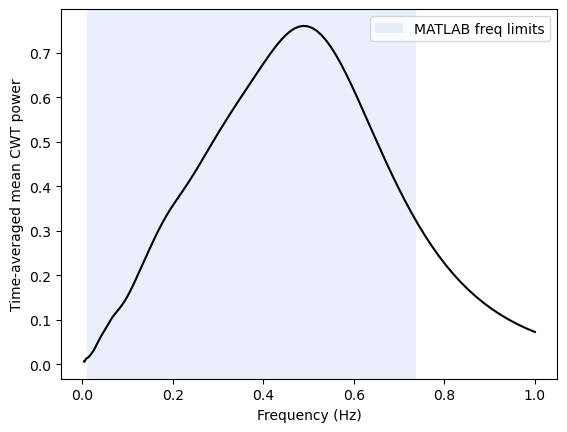

In [9]:
plt.plot(freqs, ps_mean, color='k')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Time-averaged mean CWT power')
plt.axvspan(_freq_min_matlab, _freq_max_matlab, color='royalblue', alpha=0.1, label='MATLAB freq limits', lw=0)
plt.legend()

## GM wavelet (3, 60)

In [13]:
wlt = sq.Wavelet('gmw')

In [14]:
ps = []

for xi in x:
    
    Tx, Wx, freqs, scales = sq.ssq_cwt(xi, wavelet=wlt, fs=fs)
    
    ps.append(np.mean(abs(Wx**2), axis=1))
ps = np.array(ps)    

In [15]:
ps_mean = np.mean(ps, axis=0)

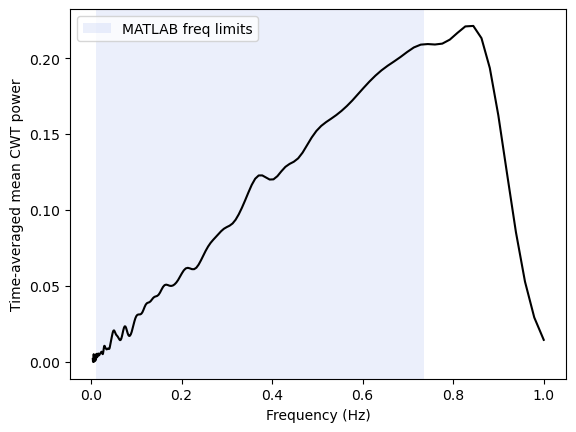

In [16]:
plt.plot(freqs, ps_mean, color='k')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Time-averaged mean CWT power')
plt.axvspan(_freq_min_matlab, _freq_max_matlab, color='royalblue', alpha=0.1, label='MATLAB freq limits', lw=0)
plt.legend()